
# MODULE 1 : Exploration, Nettoyage Intelligent et Analyse

## Étape 0 : Imports et Configuration

In [36]:
import warnings
warnings.filterwarnings("ignore")

# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# ── Classification ────────────────────────────────────────────────────────────
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# ── Clustering ────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP non installé — pip install shap")

# ── Optuna ────────────────────────────────────────────────────────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print("✅ Optuna disponible")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠️  Optuna non installé — pip install optuna")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
PALETTE = 'viridis'

print('\n✅ Imports réussis.')

⚠️  SHAP non installé — pip install shap
⚠️  Optuna non installé — pip install optuna

✅ Imports réussis.


## Étape 1 : Chargement et Exploration des Données

In [ ]:
df = pd.read_csv("eco-system.csv",
                 sep=",", header=0)

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nAperçu des premières lignes :")
df.head()

Dimensions : 10500 lignes x 9 colonnes

Aperçu des premières lignes :


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [38]:
print("Informations générales :")
df.info()

Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   str    
 7   Source            9964 non-null   str    
 8   Rapport_Collecte  10500 non-null  str    
dtypes: float64(6), str(3)
memory usage: 738.4 KB


In [39]:
print("\nVérification des NaN :")
print(df.isnull().sum())


Vérification des NaN :
Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64


In [40]:
print("Statistiques descriptives :")
df.describe(include='all')

Statistiques descriptives :


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000,9986,9964,10500
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,9336
top,NaN,NaN,NaN,NaN,NaN,NaN,Plastique,Collecte_Citoyenne,Ferraille ou métal collecté via la collecte ci...
freq,NaN,NaN,NaN,NaN,NaN,NaN,2795,2644,8
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857,NaN,NaN,NaN
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089,NaN,NaN,NaN
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000,NaN,NaN,NaN
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623,NaN,NaN,NaN
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356,NaN,NaN,NaN
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634,NaN,NaN,NaN


In [41]:
print("Distribution de la variable cible 'Categorie' :")
print(df['Categorie'].value_counts())
print("\nDistribution de 'Source' :")
print(df['Source'].value_counts())

Distribution de la variable cible 'Categorie' :
Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

Distribution de 'Source' :
Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64


## Étape 2 : Nettoyage des Valeurs Manquantes

### 2.1 — Diagnostic des valeurs manquantes

In [42]:
missing = pd.DataFrame({
    'Nombre_NaN'   : df.isnull().sum(),
    'Pourcentage_%': (df.isnull().mean() * 100).round(2)
}).sort_values('Pourcentage_%', ascending=False)

missing = missing[missing['Nombre_NaN'] > 0]
print("Colonnes avec valeurs manquantes :")
print(missing if not missing.empty else "Aucune valeur manquante détectée.")

Colonnes avec valeurs manquantes :
              Nombre_NaN  Pourcentage_%
Opacite             1035           9.86
Poids               1029           9.80
Conductivite        1017           9.69
Rigidite             558           5.31
Volume               540           5.14
Prix_Revente         536           5.10
Source               536           5.10
Categorie            514           4.90


### 2.2 — Imputation par Groupe

In [43]:
num_cols  = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
cat_cols  = ['Source']
text_cols = ['Rapport_Collecte']
target    = 'Categorie'

df_clean = df.copy()

for col in num_cols:
    group_medians_cat = df_clean.groupby(target)[col].transform('median')
    group_medians_src = df_clean.groupby('Source')[col].transform('median')
    global_median     = df_clean[col].median()
    df_clean[col] = (
        df_clean[col]
        .fillna(group_medians_cat)
        .fillna(group_medians_src)
        .fillna(global_median)
    )

print("Colonnes numériques imputées par groupe (Catégorie → Source → Global).")

Colonnes numériques imputées par groupe (Catégorie → Source → Global).


In [44]:
for col in cat_cols:
    if df_clean[col].isnull().any():
        mode_by_group = (
            df_clean.groupby(target)[col]
            .apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
        )
        def fill_cat(row):
            if pd.isnull(row[col]):
                return mode_by_group.get(row[target], df_clean[col].mode()[0])
            return row[col]
        df_clean[col] = df_clean.apply(fill_cat, axis=1)
        print(f"'{col}' imputé par le mode selon '{target}'.")
    else:
        print(f"'{col}' : aucune valeur manquante.")

'Source' imputé par le mode selon 'Categorie'.


In [45]:
print("\nVérification des NaN après imputation :")
print(df_clean.isnull().sum())


Vérification des NaN après imputation :
Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           514
Source                0
Rapport_Collecte      0
dtype: int64


## Étape 3 : Détection et Traitement des Outliers

### 3.1 — Visualisation initiale

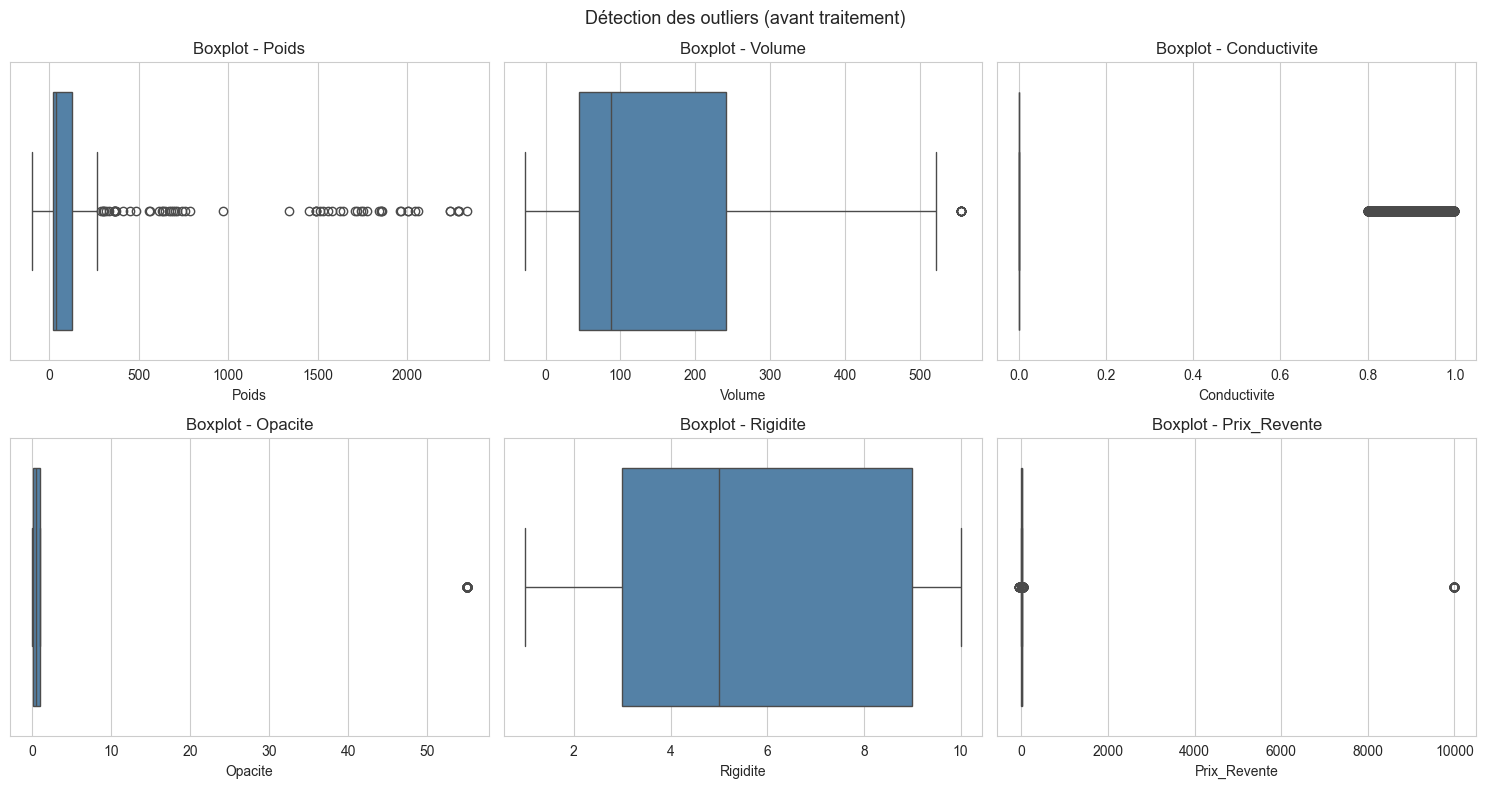

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot - {col}')
plt.suptitle('Détection des outliers (avant traitement)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 — Traitement des outliers (Capping IQR)

In [47]:
print("Détection et capping des outliers (méthode IQR globale) :")
for col in num_cols:
    Q1     = df_clean[col].quantile(0.25)
    Q3     = df_clean[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col} : {outliers} outliers détectés → capping appliqué")
    df_clean[col] = df_clean[col].clip(lower, upper)
print("\n✅ Outliers traités par capping global (IQR).")

Détection et capping des outliers (méthode IQR globale) :
  Poids : 62 outliers détectés → capping appliqué
  Volume : 12 outliers détectés → capping appliqué
  Conductivite : 2398 outliers détectés → capping appliqué
  Opacite : 97 outliers détectés → capping appliqué
  Rigidite : 0 outliers détectés → capping appliqué
  Prix_Revente : 1878 outliers détectés → capping appliqué

✅ Outliers traités par capping global (IQR).


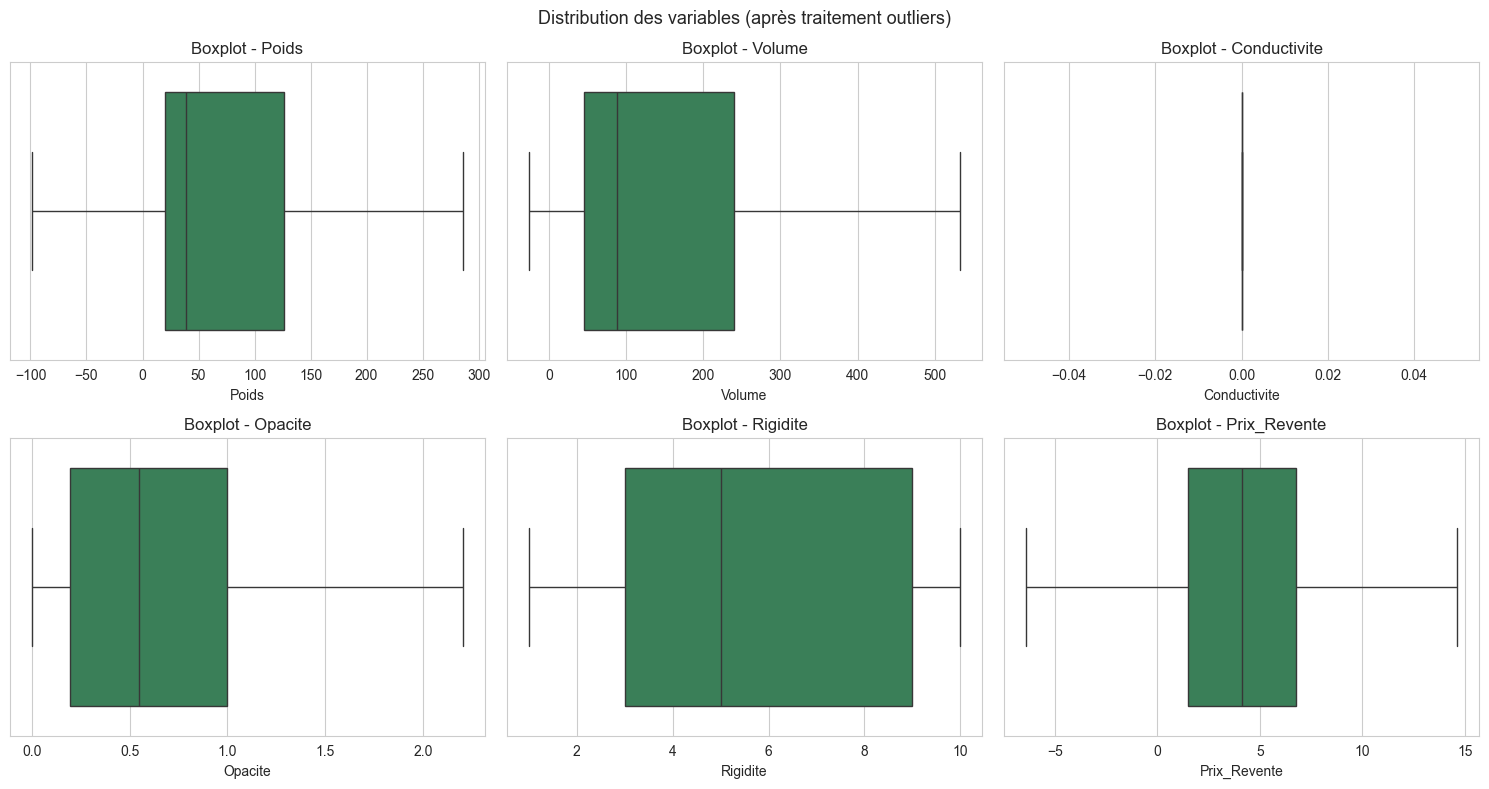

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color='seagreen')
    ax.set_title(f'Boxplot - {col}')
plt.suptitle('Distribution des variables (après traitement outliers)', fontsize=13)
plt.tight_layout()
plt.show()

## Étape 4 : Validation des Règles Métier

In [49]:
print("Vérification des valeurs négatives :")
for col in num_cols:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col} : {neg_count} valeur(s) négative(s) → remplacées par 0")
        df_clean[col] = df_clean[col].clip(lower=0)
    else:
        print(f"  {col} : ✅ OK (toutes valeurs >= 0)")

Vérification des valeurs négatives :
  Poids : 104 valeur(s) négative(s) → remplacées par 0
  Volume : 245 valeur(s) négative(s) → remplacées par 0
  Conductivite : ✅ OK (toutes valeurs >= 0)
  Opacite : ✅ OK (toutes valeurs >= 0)
  Rigidite : ✅ OK (toutes valeurs >= 0)
  Prix_Revente : 10 valeur(s) négative(s) → remplacées par 0


In [50]:
opac_invalid = ((df_clean['Opacite'] < 0) | (df_clean['Opacite'] > 1)).sum()
if opac_invalid > 0:
    print(f"Opacite : {opac_invalid} valeur(s) hors [0,1] → clippées")
    df_clean['Opacite'] = df_clean['Opacite'].clip(0, 1)
else:
    print("Opacite : ✅ toutes les valeurs sont dans [0, 1]")

n_dupl = df_clean.duplicated().sum()
print(f"Doublons détectés : {n_dupl}")
df_clean = df_clean.drop_duplicates()
print(f"Après suppression : {df_clean.shape[0]} lignes conservées.")

Opacite : 97 valeur(s) hors [0,1] → clippées
Doublons détectés : 880
Après suppression : 9620 lignes conservées.


## Étape 5 : Feature Engineering — Normalisation et Standardisation

In [51]:
scaler_std = StandardScaler()
df_std = df_clean.copy()
df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])
print("Colonnes standardisées (StandardScaler — μ=0, σ=1) :")
print(df_std[num_cols].describe().loc[['mean', 'std']].round(4))

Colonnes standardisées (StandardScaler — μ=0, σ=1) :
       Poids  Volume  Conductivite  Opacite  Rigidite  Prix_Revente
mean -0.0000  0.0000           0.0  -0.0000   -0.0000       -0.0000
std   1.0001  1.0001           0.0   1.0001    1.0001        1.0001


In [52]:
scaler_mm = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[num_cols] = scaler_mm.fit_transform(df_norm[num_cols])
print("Colonnes normalisées (MinMaxScaler — [0,1]) :")
print(df_norm[num_cols].describe().loc[['min', 'max']].round(4))

Colonnes normalisées (MinMaxScaler — [0,1]) :
     Poids  Volume  Conductivite  Opacite  Rigidite  Prix_Revente
min    0.0     0.0           0.0      0.0       0.0           0.0
max    1.0     1.0           0.0      1.0       1.0           1.0


## Étape 6 : Encodage des Variables Catégoriques

In [53]:
print("Valeurs uniques de Source   :", df_clean['Source'].value_counts().to_dict())
print("Valeurs uniques de Categorie:", df_clean['Categorie'].value_counts().to_dict())

Valeurs uniques de Source   : {'Collecte_Citoyenne': 2820, 'Usine_A': 2480, 'Centre_Tri': 2193, 'Usine_B': 2127}
Valeurs uniques de Categorie: {'Plastique': 2544, 'Verre': 2356, 'Métal': 2124, 'Papier': 2085}


In [54]:
le_source = LabelEncoder()
le_target = LabelEncoder()

df_clean['Source']    = le_source.fit_transform(df_clean['Source'])
df_clean['Categorie'] = le_target.fit_transform(df_clean['Categorie'])

print("Encodage Source    :", dict(zip(le_source.classes_, le_source.transform(le_source.classes_))))
print("Encodage Categorie :", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print("\n", df_clean.dtypes)

Encodage Source    : {'Centre_Tri': np.int64(0), 'Collecte_Citoyenne': np.int64(1), 'Usine_A': np.int64(2), 'Usine_B': np.int64(3)}
Encodage Categorie : {'Métal': np.int64(0), 'Papier': np.int64(1), 'Plastique': np.int64(2), 'Verre': np.int64(3), nan: np.int64(4)}

 Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie             int64
Source                int64
Rapport_Collecte        str
dtype: object


## Étape 7 : Analyse Exploratoire

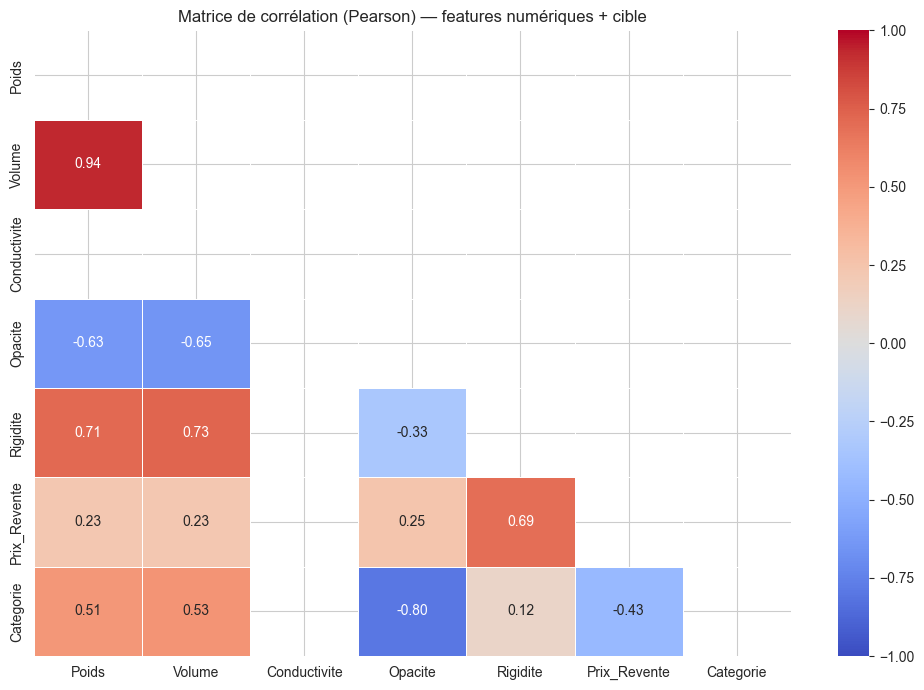

In [55]:
plt.figure(figsize=(10, 7))
corr = df_clean[num_cols + ['Categorie']].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice de corrélation (Pearson) — features numériques + cible')
plt.tight_layout()
plt.show()